Opening file selector...
Selected: C:/Users/kanha/Documents/MachLeData/src/data/imageData/005BA4D8-AAE4-4E17-8A8A-8017E3EF48F7_2024-02-28-11-44-26_image.jpg
Initializing MiDaS Small on cpu...


Using cache found in C:\Users\kanha/.cache\torch\hub\intel-isl_MiDaS_master


Loading weights:  None


Using cache found in C:\Users\kanha/.cache\torch\hub\rwightman_gen-efficientnet-pytorch_master
Using cache found in C:\Users\kanha/.cache\torch\hub\intel-isl_MiDaS_master


Running depth inference...


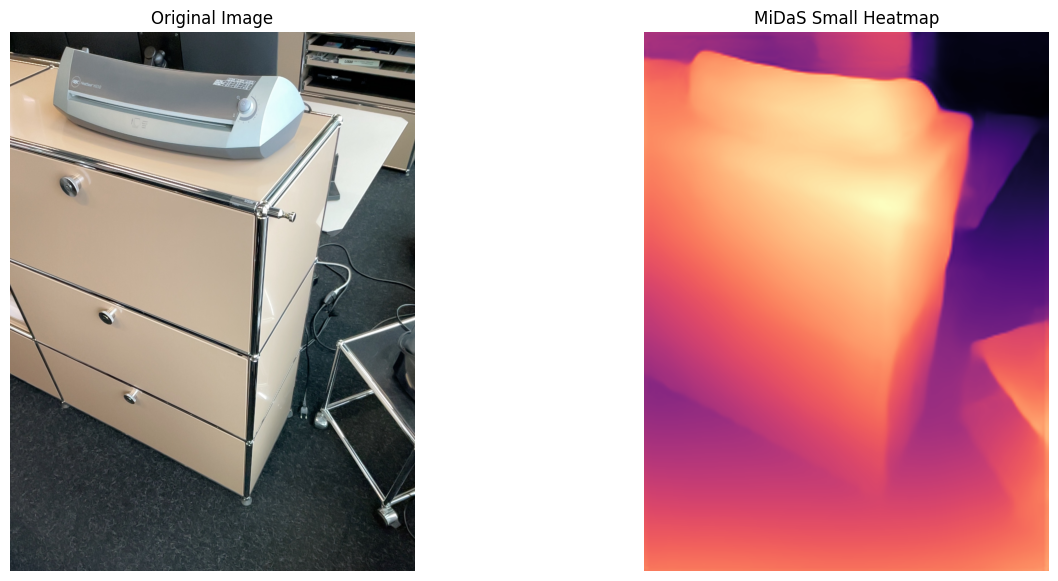

Heatmap saved to: C:\Users\kanha\Documents\MachLeData\src\data\MidasHeatMap\midas_small_heatmap.png


In [4]:
import os
import torch
import cv2
import numpy as np
import matplotlib.pyplot as plt
import tkinter as tk
from tkinter import filedialog

# ==========================================================
# 1. PATH SETUP
# ==========================================================
current_dir = os.getcwd()
if os.path.basename(current_dir) == 'notebooks':
    BASE_DIR = os.path.dirname(current_dir)
else:
    BASE_DIR = current_dir

# ==========================================================
# 2. FILE SELECTION FUNCTION (Windows Native)
# ==========================================================
def select_image_file():
    """Opens a Windows File Explorer dialog to pick an image."""
    root = tk.Tk()
    root.withdraw()      # Hide the main tkinter window
    root.attributes("-topmost", True) # Bring to front
    
    file_path = filedialog.askopenfilename(
        title="Select an Image for MiDaS Depth Map",
        filetypes=[("Image Files", "*.jpg *.jpeg *.png *.bmp *.webp"), ("All Files", "*.*")]
    )
    
    root.destroy()
    return file_path

# ==========================================================
# 3. MAIN EXECUTION PIPELINE
# ==========================================================
def main():
    # --- Step A: Select Image ---
    print("Opening file selector...")
    selected_path = select_image_file()
    
    if not selected_path:
        print("No file selected. Operation cancelled.")
        return
    
    print(f"Selected: {selected_path}")

    # --- Step B: Setup MiDaS Small ---
    DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
    print(f"Initializing MiDaS Small on {DEVICE}...")
    
    model_type = "MiDaS_small"
    midas = torch.hub.load("intel-isl/MiDaS", model_type)
    midas.to(DEVICE).eval()

    midas_transforms = torch.hub.load("intel-isl/MiDaS", "transforms")
    transform = midas_transforms.small_transform

    # --- Step C: Process Image ---
    raw_image = cv2.imread(selected_path)
    img_rgb = cv2.cvtColor(raw_image, cv2.COLOR_BGR2RGB)
    
    print("Running depth inference...")
    input_batch = transform(img_rgb).to(DEVICE)

    with torch.no_grad():
        prediction = midas(input_batch)
        # Resize to original image size
        prediction = torch.nn.functional.interpolate(
            prediction.unsqueeze(1),
            size=img_rgb.shape[:2],
            mode="bicubic",
            align_corners=False,
        ).squeeze()

    depth = prediction.cpu().numpy()

    # --- Step D: Normalize and Create Heatmap ---
    # Normalize to 0-255 for visualization
    depth_norm = cv2.normalize(depth, None, 0, 255, norm_type=cv2.NORM_MINMAX, dtype=cv2.CV_8U)
    
    # Create the heatmap (Magma/Spectral style)
    heatmap = cv2.applyColorMap(depth_norm, cv2.COLORMAP_MAGMA)
    heatmap_rgb = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)

    # --- Step E: Visualization ---
    plt.figure(figsize=(15, 7))
    plt.subplot(1, 2, 1)
    plt.title("Original Image")
    plt.imshow(img_rgb)
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.title("MiDaS Small Heatmap")
    plt.imshow(heatmap_rgb)
    plt.axis('off')
    
    plt.show()

    # --- Step F: Save Output ---
    out_dir = os.path.join(BASE_DIR, 'src', 'data',"MidasHeatMap")
    os.makedirs(out_dir, exist_ok=True)
    save_path = os.path.join(out_dir, "midas_small_heatmap.png")
    cv2.imwrite(save_path, heatmap)
    print(f"Heatmap saved to: {save_path}")

if __name__ == "__main__":
    main()